<a href="https://colab.research.google.com/github/nangulo2132/ML-Final-Project/blob/main/MLFinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

def read_lodes_data(
    data_type,
    state,
    segment,
    job_type,
    year,
    main=True,
    base="https://lehd.ces.census.gov/data/lodes/LODES8/",
):
    """
    Reads LODES RAC, WAC, or OD data based on the specified type.

    Parameters:
    - data_type (str): One of 'rac', 'wac', or 'od' to specify the dataset.
    - state (str): Lowercase two-character state abbreviation (e.g., 'nj').
    - segment (str): Segment type (e.g., 'SA01'). Ignored if 'data_type' is 'od'.
    - job_type (str): Job type (e.g., 'JT00').
    - year (int): Year of data (e.g., 2004).
    - main (bool): Whether to read the 'main' file type. Only used if 'data_type' is 'od'.
    - base (str): Base file path to read data from. Can be URL or local file path.

    Returns:
    - pd.DataFrame: The requested LODES dataset as a pandas DataFrame.
    """
    if data_type not in ["rac", "wac", "od"]:
        raise ValueError("Invalid data type. Choose from 'rac', 'wac', or 'od'.")
    if data_type == "od":
        if main:
            file_url = f"{base}{state}/od/{state}_od_main_{job_type}_{year}.csv.gz"
        else:
            file_url = f"{base}{state}/od/{state}_od_aux_{job_type}_{year}.csv.gz"
        dtype_mapping = {"h_geocode": str, "w_geocode": str}
    else:
        file_url = f"{base}{state}/{data_type}/{state}_{data_type}_{segment}_{job_type}_{year}.csv.gz"
        dtype_mapping = {"h_geocode": str} if data_type == "rac" else {"w_geocode": str}
    return pd.read_csv(file_url, dtype=dtype_mapping)

def read_crosswalk(
    state, cols="all", base="https://lehd.ces.census.gov/data/lodes/LODES8/"
):
    """
    Reads LODES Geography Crosswalk given state.

    Parameters:
    - state (str): Lowercase two-character state abbreviation (e.g., 'nj').
    - cols (list): List of columns to read from the crosswalk in addition to tabblk2020 (Block ID). If "all", all columns will be read and returned.
    - base (str): Base file path to read data from. Can be URL or local file path.

    Returns:
    - pd.DataFrame: The requested LODES crosswalk as a pandas DataFrame.
    """
    file_url = f"{base}{state}/{state}_xwalk.csv.gz"
    dtype_mapping = str
    if cols == "all":
        return pd.read_csv(file_url, dtype=dtype_mapping)
    cols.insert(0, "tabblk2020")
    return pd.read_csv(file_url, dtype=dtype_mapping, usecols=cols)

In [ ]:
import geopandas as gpd

# Read in MTA data
mta_stations = gpd.read_file("/content/MTA_Subway_Stations_20260330.geojson")

# Convert to projection for contiguous USA
mta_stations = mta_stations.to_crs("ESRI:102003")

# Buffer mta stations by 805 meters (approximately 0.5 miles)
mta_stations["geometry"] = mta_stations.geometry.buffer(805)


In [ ]:
# Read in OD data
all_od = []
states = ["ny"]

# Years between 2021 (inclusive) and 2024 (exclusive)
year_range = list(range(2021, 2024))
for state in states:
    for year in year_range:
        main = read_lodes_data(
            data_type="od",
            state=state,
            segment=None,
            job_type="JT01",
            year=year,
            main=True,
        )
        main["year"] = year
        all_od.append(main)
        aux = read_lodes_data(
            data_type="od",
            state=state,
            segment=None,
            job_type="JT01",
            year=year,
            main=False,
        )
        aux["year"] = year
        all_od.append(aux)

# Concatenate all OD files
all_od = pd.concat(all_od)

# NYC county FIPS codes
nyc_counties = ["36061", "36047", "36081", "36005", "36085"]

# Extract county FIPS from geocode (first 5 digits)
all_od["w_county"] = all_od["w_geocode"].astype(str).str[:5]
all_od["h_county"] = all_od["h_geocode"].astype(str).str[:5]

# Keep OD pairs where either home OR work is in NYC
all_od_nyc = all_od[
    (all_od["w_county"].isin(nyc_counties)) |
    (all_od["h_county"].isin(nyc_counties))
]

print(all_od_nyc.head())

           w_geocode        h_geocode  S000  SA01  SA02  SA03  SE01  SE02  \
61   360010001001005  360471210002000     1     1     0     0     0     0   
64   360010001001005  360610090006000     1     0     1     0     0     0   
196  360010001001007  360850134001007     1     1     0     0     0     1   
355  360010001001019  360610144012000     1     0     0     1     0     1   
360  360010001001019  360811163011000     1     0     1     0     0     0   

     SE03  SI01  SI02  SI03  createdate  year w_county h_county  
61      1     0     0     1    20231016  2021    36001    36047  
64      1     0     0     1    20231016  2021    36001    36061  
196     0     0     1     0    20231016  2021    36001    36085  
355     0     0     0     1    20231016  2021    36001    36061  
360     1     0     0     1    20231016  2021    36001    36081  


In [ ]:
all_crosswalks = []
states = ["ny"]

for state in states:
    all_crosswalks.append(
        read_crosswalk(state=state, cols=["blklatdd", "blklondd"])
    )

all_crosswalks = pd.concat(all_crosswalks, ignore_index=True)

all_crosswalks = all_crosswalks.rename(columns={
    "tabblk2020": "geocode"
})

# Ensure proper formatting, using 'geocode' which is the block ID
all_crosswalks["geocode"] = (all_crosswalks["geocode"].astype(str).str.zfill(15))

# Workplace coords
all_od_nyc = all_od_nyc.merge(
    all_crosswalks.rename(columns={
        "geocode": "w_geocode",
        "blklatdd": "w_lat",
        "blklondd": "w_lon"
    }),
    on="w_geocode",
    how="left"
)

# Home coords
all_od_nyc = all_od_nyc.merge(
    all_crosswalks.rename(columns={
        "geocode": "h_geocode",
        "blklatdd": "h_lat",
        "blklondd": "h_lon"
    }),
    on="h_geocode",
    how="left"
)


NameError: name 'all_od_nyc' is not defined

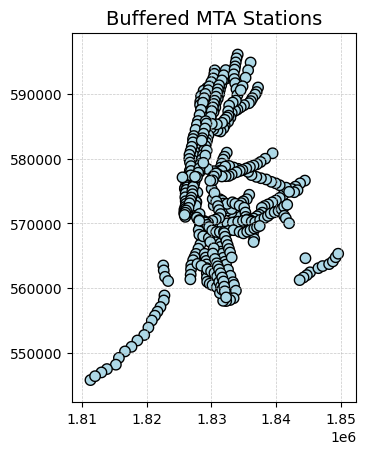

In [ ]:
import matplotlib.pyplot as plt

# Create plot and plot stations
fig, ax = plt.subplots()
mta_stations.plot(ax=ax, color="lightblue", edgecolor="black")

# Add title
ax.set_title("Buffered MTA Stations", fontsize=14)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)


In [ ]:
# Convert crosswalk to geographic dataframe
all_crosswalks = gpd.GeoDataFrame(
    all_crosswalks,
    geometry=gpd.points_from_xy(all_crosswalks["blklondd"], all_crosswalks["blklatdd"]),
    crs="EPSG:4326",
)

# Convert to projection for contiguous USA
all_crosswalks = all_crosswalks.to_crs("ESRI:102003")

# Spatial join using 'intersects'
blocks_within_buffers = gpd.sjoin(
    all_crosswalks, mta_stations, predicate="intersects"
)

print(blocks_within_buffers.head())

           tabblk2020    blklatdd     blklondd  \
8118  360050019011000  40.8092644  -73.9289432   
8118  360050019011000  40.8092644  -73.9289432   
8119  360050019011001  40.8092677  -73.9291323   
8119  360050019011001  40.8092677  -73.9291323   
8120  360050019011002  40.8083912  -73.9274375   

                            geometry  index_right                 :id  \
8118  POINT (1830100.671 584322.601)          377  row-b44u.bqnu~jcys   
8118  POINT (1830100.671 584322.601)          391  row-4tpr.sfpy-ga7h   
8119  POINT (1830085.189 584319.319)          377  row-b44u.bqnu~jcys   
8119  POINT (1830085.189 584319.319)          391  row-4tpr.sfpy-ga7h   
8120  POINT (1830245.778 584256.433)          376  row-as5r_recr.se5a   

               :version                      :created_at  \
8118  rv-am8h~57wp_wqj6 2026-03-30 04:11:54.580000+00:00   
8118  rv-54m8.y7wr-8z9b 2026-03-30 04:11:54.580000+00:00   
8119  rv-am8h~57wp_wqj6 2026-03-30 04:11:54.580000+00:00   
8119  rv-54m8.y7wr-8

In [ ]:
# Get list of blocks within the buffer
include_blocks = blocks_within_buffers["tabblk2020"].to_list()

# Filter for rows in which home and work are in buffered list
limited_od = all_od[
    (all_od["h_geocode"].isin(include_blocks))
    & (all_od["w_geocode"]).isin(include_blocks)
]

# Group and sum total jobs by year
jobs_by_year = limited_od[["S000", "year"]].groupby("year").sum().reset_index()

print(jobs_by_year)

   year     S000
0  2021  1659453
1  2022  1820830
2  2023  1879952
